**GNCIPL_TASK-1 - Hospital Patient Admission Trends** --Prajna Mondal

Analyzed hospital patient admission data using Python, Pandas, and data visualization techniques to identify monthly admission trends, department-wise patient distribution, age-group patterns, and seasonal illness trends. Developed insights to support healthcare resource planning and decision-making.


Project Goal

The goal of this project is to analyze historical hospital patient admission data and identify important trends and patterns. The analysis helps understand:

1.When the highest number of patients are admitted.

2.Which hospital department receives the most patients.

3.Which age group has the highest admission rate.

4.Which diseases are more common during specific seasons or months.

5.How patient admissions may change in the future.

1.Required Libraries Install

In [ ]:
pip install pandas numpy matplotlib seaborn plotly scikit-learn

In [ ]:
pip install openpyxl

2.Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GNCIPL_task-1.xlsx to GNCIPL_task-1.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("GNCIPL_task-1.xlsx")
df.head()

,Patient_ID,Admission_Date,Discharge_Date,Age,Gender,Department,Diagnosis,Admission_Type,Insurance_Type,Doctor_ID,Room_No,Length_of_Stay,Treatment_Cost,City,State,Blood_Group,Marital_Status,Followup_Required,Severity_Level,Outcome
0,P00001,2024-11-11,2024-11-23,74.0,Male,ENT,Diabetes,Routine,Self-Pay,D827,874,12,76844.0,Charlesville,Florida,O+,Married,No,Low,Referred
1,P00002,2025-09-08,2025-09-16,46.0,Male,Oncology,Asthma,Referral,Government,D652,227,8,32944.0,East Brandon,Tennessee,O+,Married,No,Low,Referred
2,P00003,08-07-2023,2023-07-15,43.0,Male,Pediatrics,Flu,Referral,NaN,D517,205,7,114267.0,Lake Natasha,Indiana,AB+,Married,Yes,High,Recovered
3,P00004,2024-08-31,2024-09-10,13.0,Male,Oncology,Fracture,Routine,Self-Pay,D726,254,10,75195.0,West Sethberg,Alabama,A-,Married,No,High,Recovered
4,P00005,2024-07-30,2024-07-31,46.0,Male,Neurology,COVID-19,Routine,Government,D586,926,1,130919.0,Lake Jamieberg,Wyoming,A+,Single,Yes,Low,Recovered


3.Data Cleaning

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Admission_Date,0
Discharge_Date,0
Age,516
Gender,486
Department,483
Diagnosis,515
Admission_Type,0
Insurance_Type,519
Doctor_ID,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], format='mixed', dayfirst=True)

4.Feature Engineering

4.1.Extract Month

In [ ]:
df['Month'] = df['Admission_Date'].dt.month_name()

4.2.Create Age Groups

In [ ]:
bins = [0,18,35,50,65,100]

labels = ['Child','Young Adult','Adult','Senior','Old']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

5.Analysis 1 → Monthly Admissions

<Axes: xlabel='Month'>

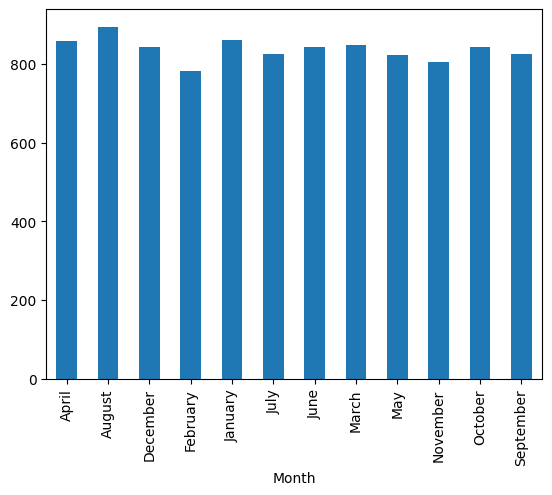

In [ ]:
monthly = df.groupby('Month').size()

monthly.plot(kind='bar')

6.Analysis 2 → Department Wise Admissions

<Axes: xlabel='Department'>

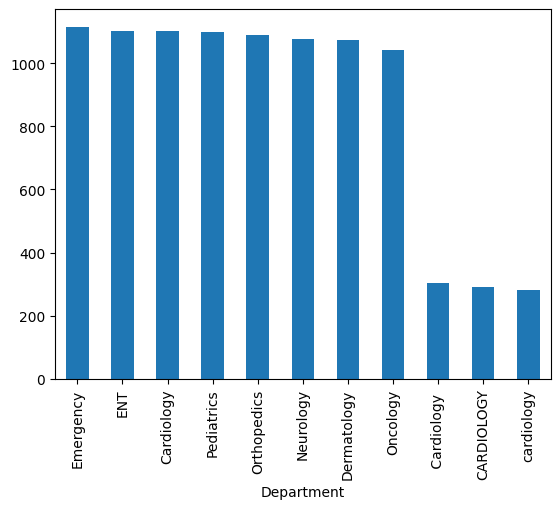

In [ ]:
dept = df['Department'].value_counts()

dept.plot(kind='bar')

7.Analysis 3 → Age Group Analysis

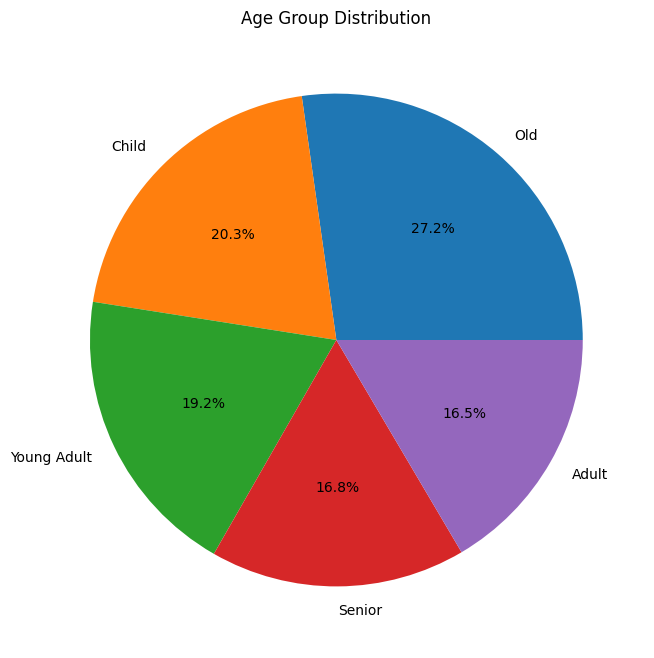

In [ ]:
import matplotlib.pyplot as plt

age = df['Age_Group'].value_counts()

age.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Age Group Distribution')
plt.ylabel('')
plt.show()

8.Analysis 4 → Seasonal Illness Trend

In [ ]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

df = df.sort_values('Month')

In [ ]:
pd.crosstab(df['Month'], df['Diagnosis'])

Diagnosis,Asthma,COVID-19,Cancer,Diabetes,Flu,Fracture,Hypertension,Migraine
Month,,,,,,,,
January,103,118,93,100,113,99,104,83
February,90,93,93,99,84,92,97,95
March,109,99,97,94,115,84,97,104
April,99,111,112,100,103,87,112,97
May,100,103,87,87,91,108,96,105
June,104,91,105,108,104,111,95,94
July,91,83,102,121,96,95,104,92
August,89,98,104,119,114,104,104,113
September,100,94,110,100,95,91,94,95


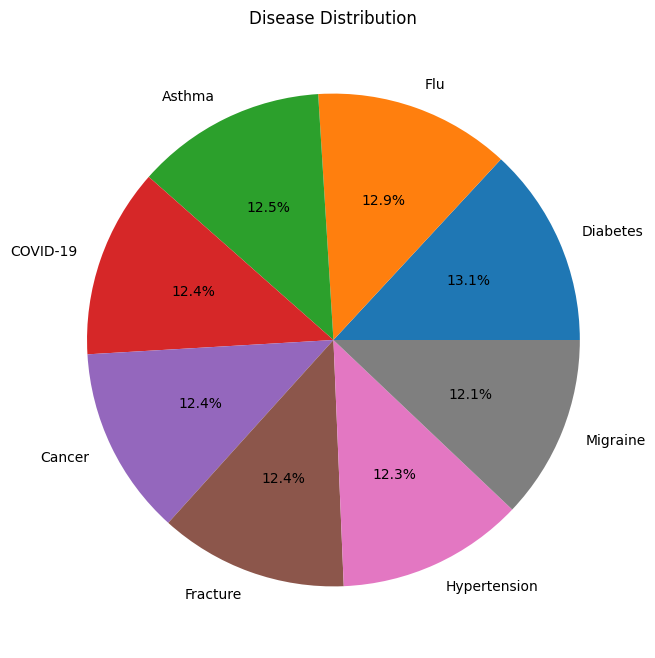

In [ ]:
import matplotlib.pyplot as plt
diagnosis_count = df['Diagnosis'].value_counts()

diagnosis_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Disease Distribution')
plt.ylabel('')
plt.show()

9.Machine Learning Part

In [ ]:
monthly_data = df.groupby('Month').size()

In [ ]:
from sklearn.linear_model import LinearRegression

X = [[1],[2],[3],[4],[5],[6],[7],[8],[9],[10],[11],[12]]

y = monthly_data.values

model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [ ]:
prediction = model.predict([[13]])

print("Predicted Admissions:", round(prediction[0]))

Predicted Admissions: 817
